In [1]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
ckpt_files = glob.glob(f"./hww_pcres_regressor/logs/version_0/checkpoints/*")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Using checkpoint: ./hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=272-val_loss=32.75.ckpt


In [3]:
dm = train.main(train=False) # Retrieve datamodule used in training
model = LightningWBoson.load_from_checkpoint(ckpt_path) # Load model from checkpoint
model.eval()

# Get the test dataloader
dm.setup(stage="test")
test_loader = dm.test_dataloader()

# Run inference
predictions = np.empty([0, dm.X.shape[1]-2]) # Without including W0 and W1 mass
true_labels = np.empty([0, dm.Y.shape[1]])
train_features = np.empty([0, dm.X.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for batch in test_loader:
        inputs, targets = batch
        inputs = inputs.to(device)
        targets = targets.to(device)
    
        outputs = model(inputs)
        
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...


Training objects shape: (1460585, 10)
Target objects shape: (1460585, 10)
Loading model from checkpoint for evaluation... return datamodule


In [4]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

In [5]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), unit="GeV"):
	plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
	plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
	plt.legend()
	plt.xlabel(unit, loc="right")
	plt.ylabel("Counts", loc="top")
	plt.title(name, loc="right")
	plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), log=False, unit="GeV"):
    if log:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=LogNorm())
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1)
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}", loc="right")
    plt.colorbar(label="Counts")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    plt.show()

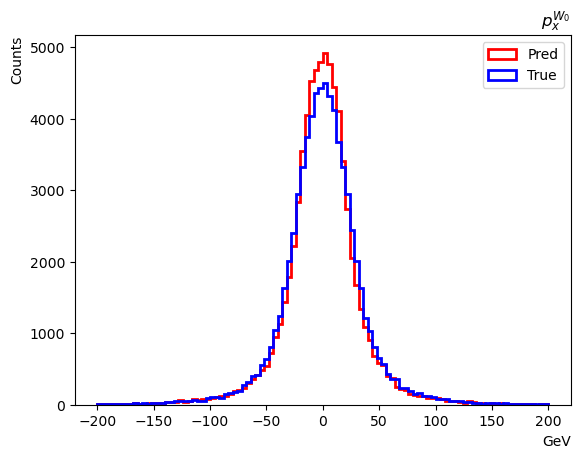

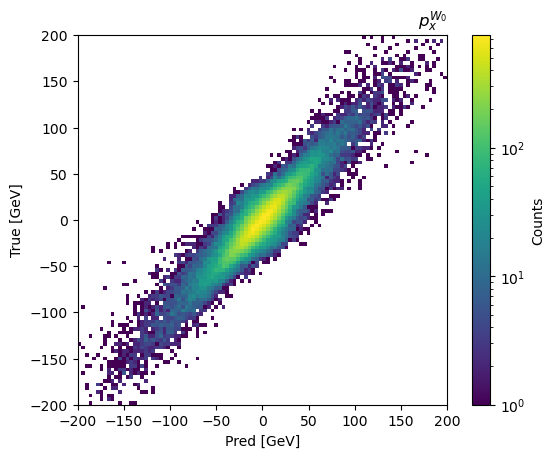

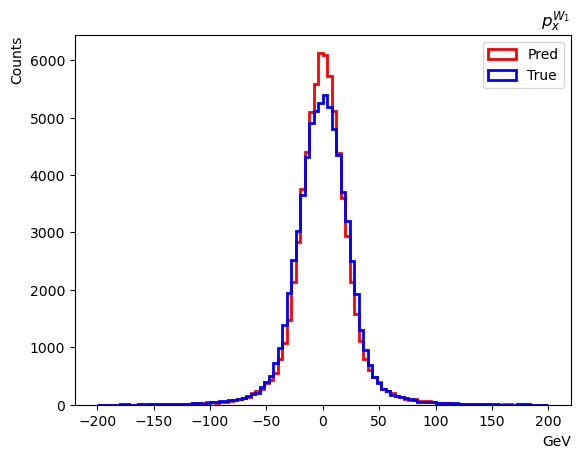

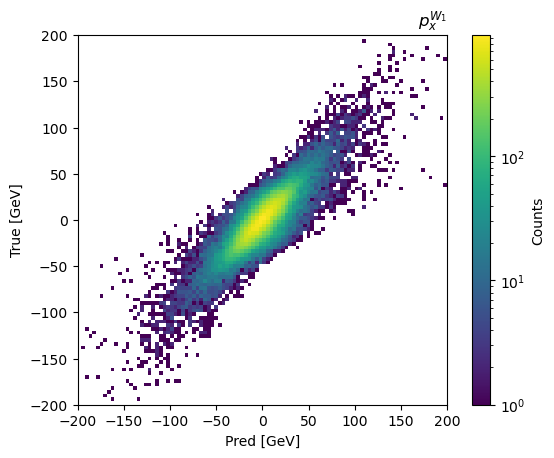

In [6]:
bins = np.linspace(-200, 200, 101)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W_0}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W_0}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W_1}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W_1}$", bins_edges=bins, log=True)

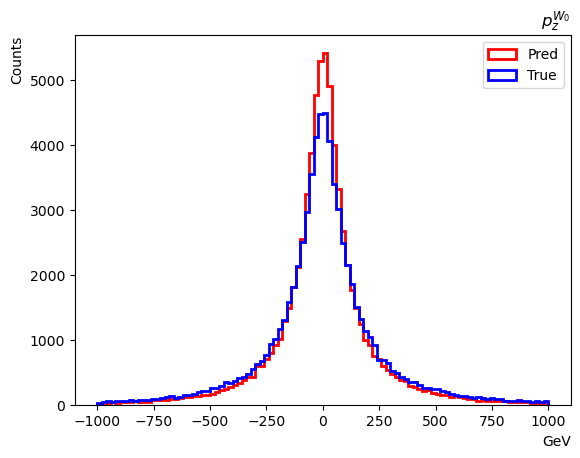

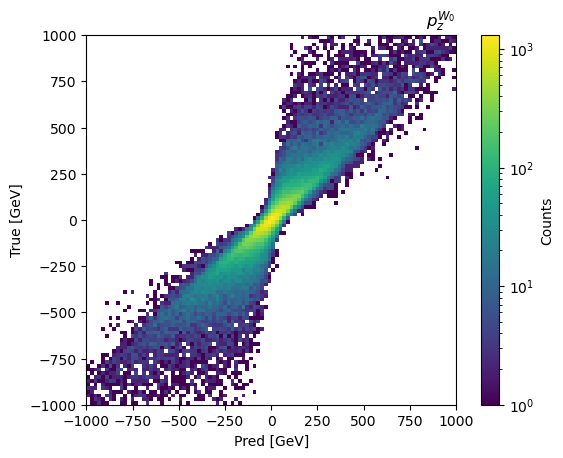

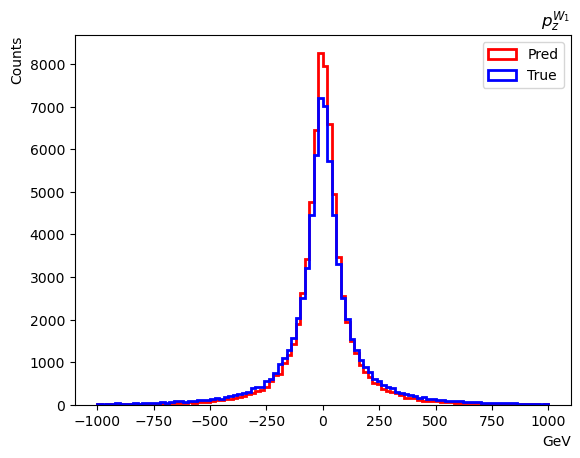

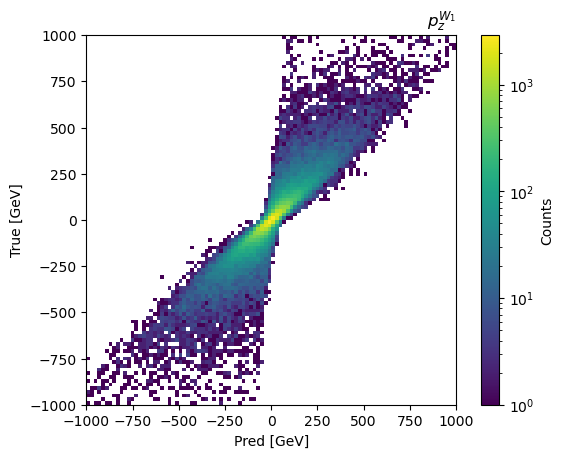

In [7]:
bins = np.linspace(-1000, 1000, 101)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W_0}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W_0}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W_1}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W_1}$", bins_edges=bins, log=True)

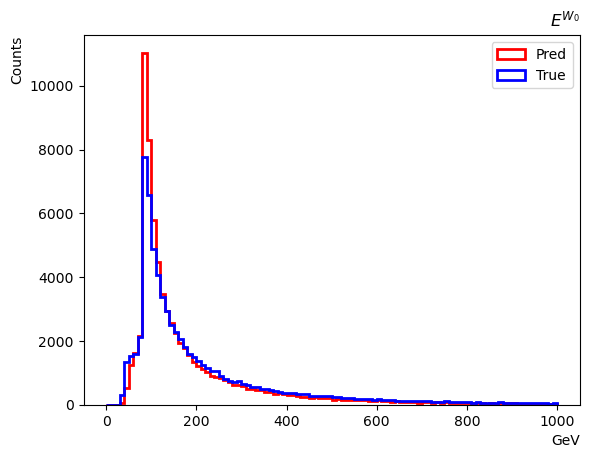

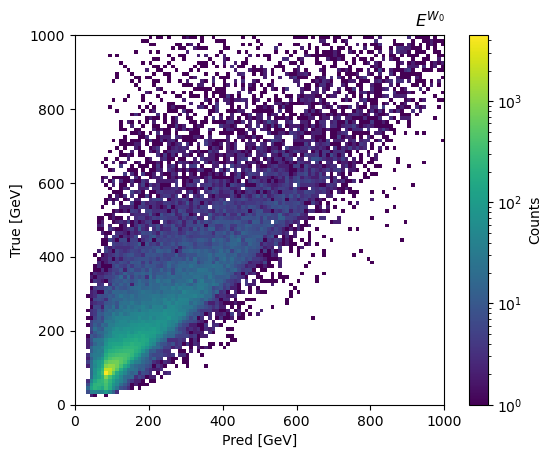

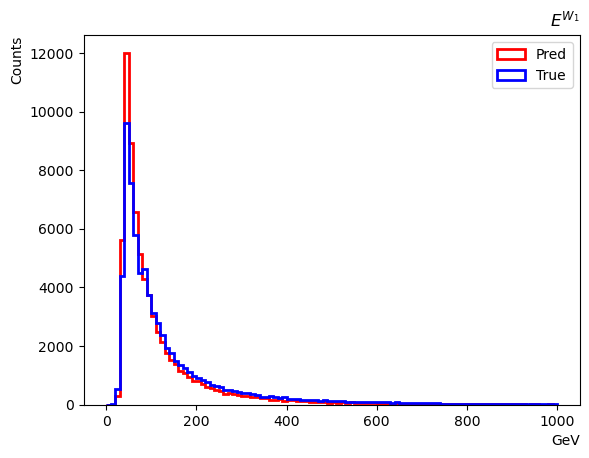

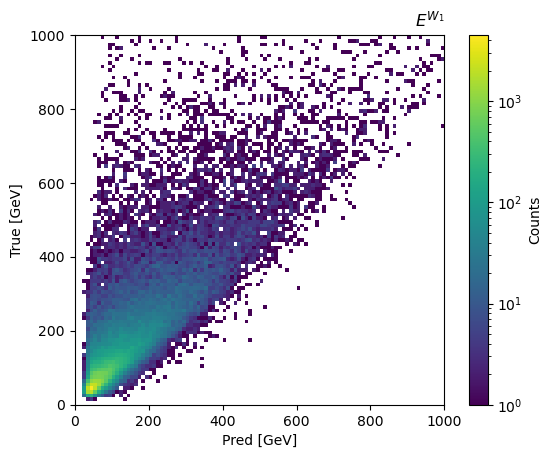

In [8]:
bins = np.linspace(0, 1000, 101)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W_0}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W_0}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W_1}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W_1}$", bins_edges=bins, log=True)

/tmp/ipykernel_304458/1269855937.py:2: RuntimeWarning: invalid value encountered in sqrt
  plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W_0}$", unit="GeV$^2$")


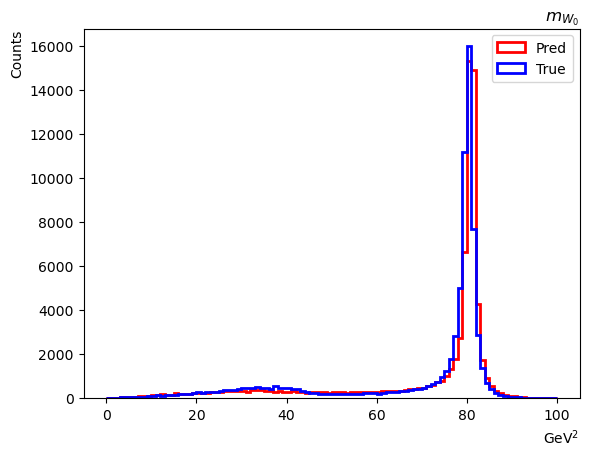

/tmp/ipykernel_304458/1269855937.py:3: RuntimeWarning: invalid value encountered in sqrt
  plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W_0}$", bins_edges=bins, log=True, unit="GeV$^2$")


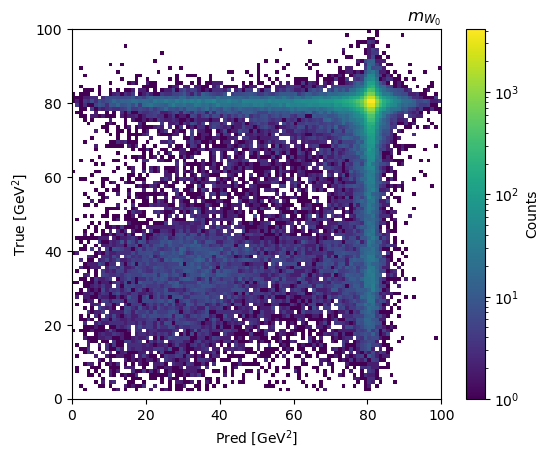

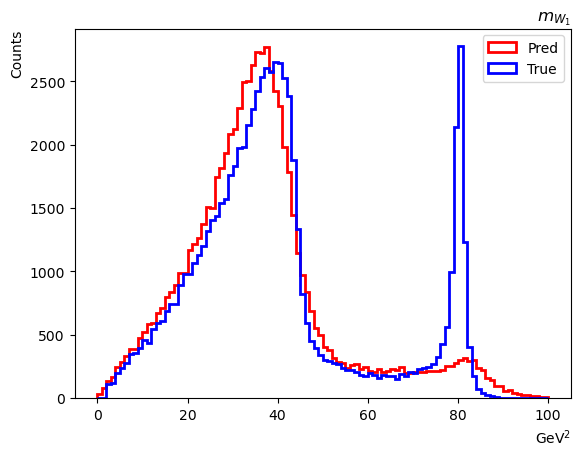

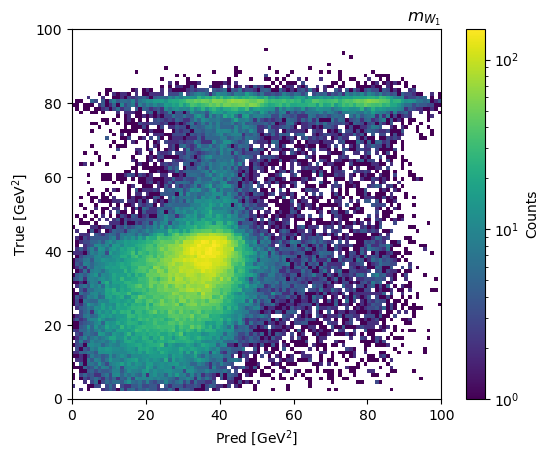

In [9]:
bins = np.linspace(0, 100, 101)
plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W_0}$", unit="GeV$^2$")
plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W_0}$", bins_edges=bins, log=True, unit="GeV$^2$")
plot_1d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W_1}$", unit="GeV$^2$")
plot_2d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), name=r"$m_{W_1}$", bins_edges=bins, log=True, unit="GeV$^2$")

Found log directories: ['./hww_pcres_regressor/logs/version_0']


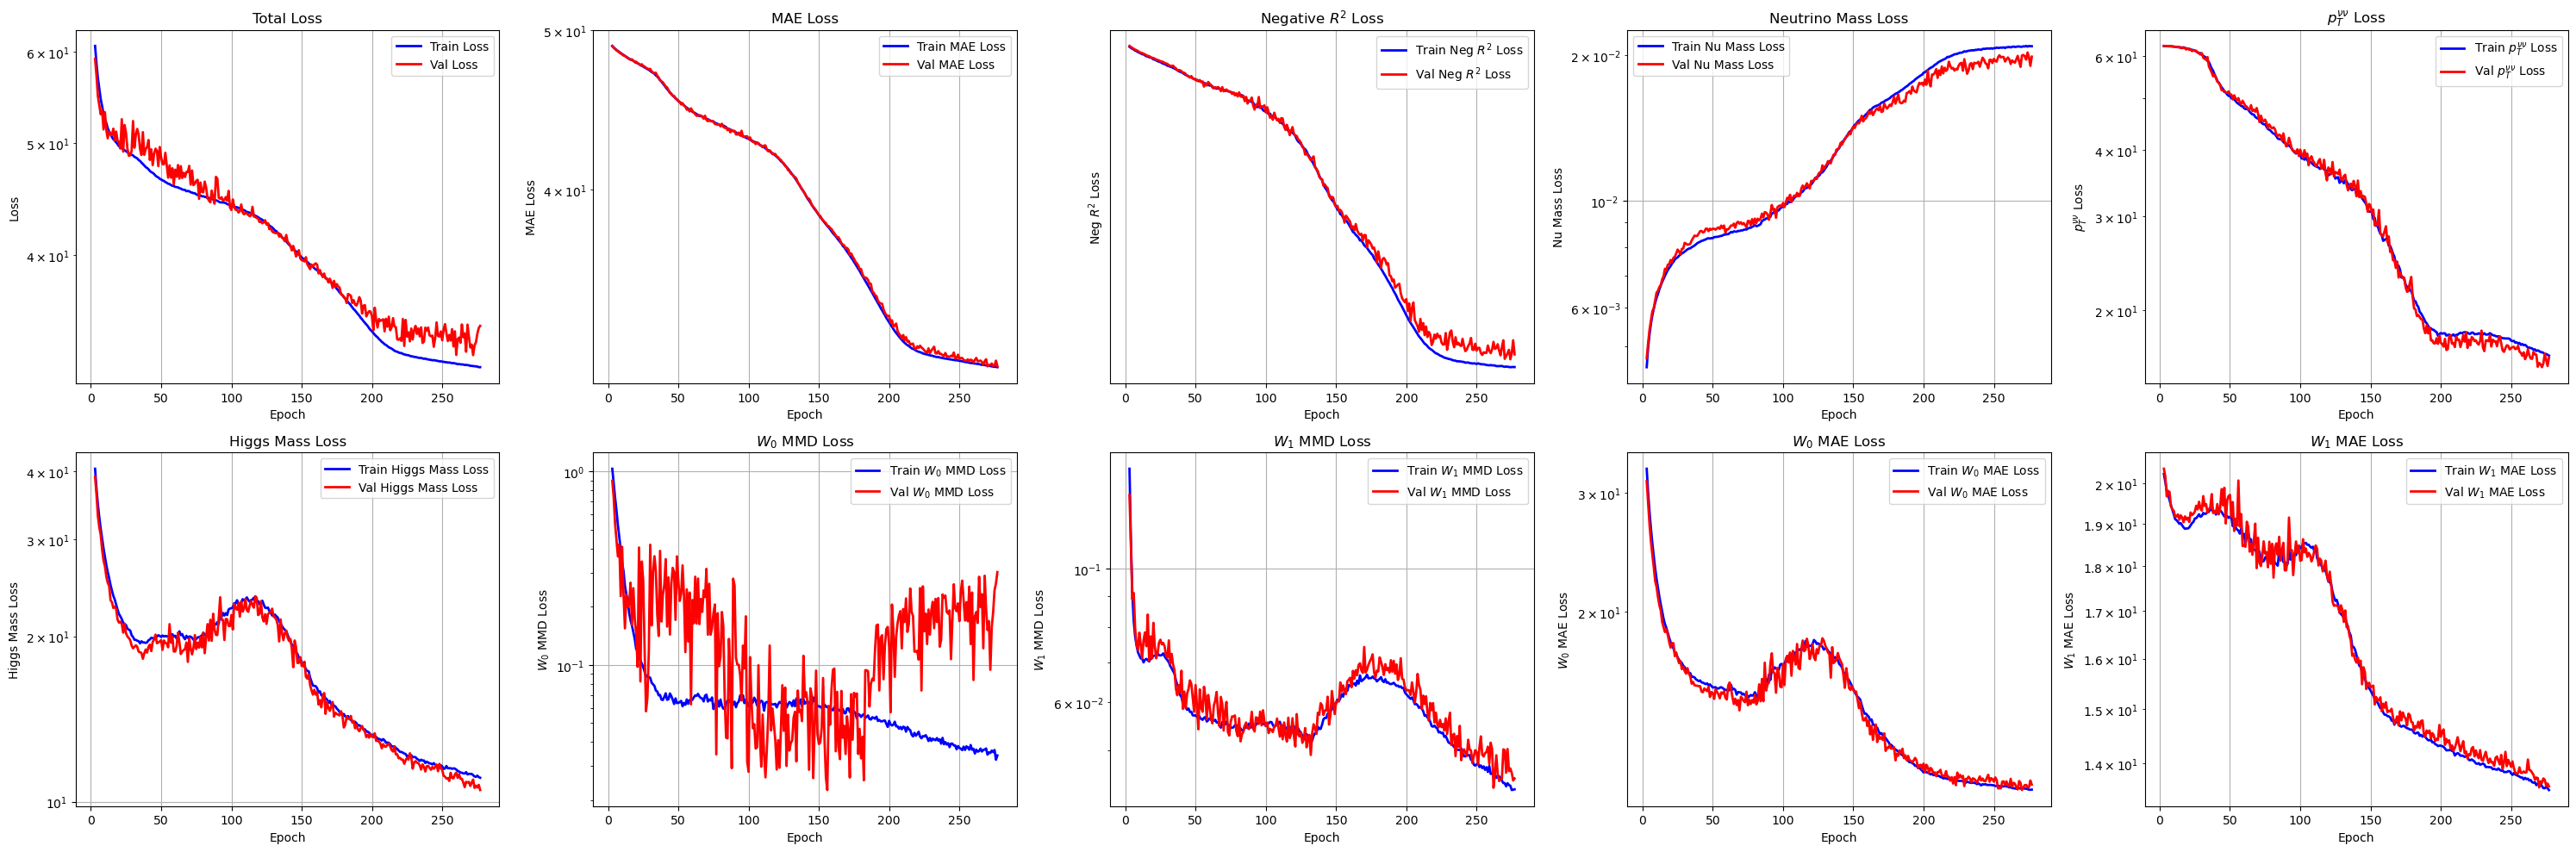


Final Training Losses (Epoch 277):
  Total Loss: 31.971928
  MAE Loss: 31.201448
  Negative $R^2$ Loss: -0.833139
  Neutrino Mass Loss: 0.020861
  $p^{\nu\nu}_T$ Loss: 16.454018
  Higgs Mass Loss: 11.055355
  $W_0$ MMD Loss: 0.034018
  $W_1$ MMD Loss: 0.043032
  $W_0$ MAE Loss: 10.912055
  $W_1$ MAE Loss: 13.536811

Final Validation Losses:
  Total Loss: 34.717316
  MAE Loss: 31.250875
  Negative $R^2$ Loss: -0.827015
  Neutrino Mass Loss: 0.019850
  $p^{\nu\nu}_T$ Loss: 16.323503
  Higgs Mass Loss: 10.498879
  $W_0$ MMD Loss: 0.301786
  $W_1$ MMD Loss: 0.044858
  $W_0$ MAE Loss: 11.099555
  $W_1$ MAE Loss: 13.599864


In [10]:
log_dirs = glob.glob("./hww_pcres_regressor/logs/*")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 10))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("mae_loss", "val_mae_loss", "MAE Loss", "MAE Loss"),
                ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W_0$ MMD Loss", "$W_0$ MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W_1$ MMD Loss", "$W_1$ MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W_0$ MAE Loss", "$W_0$ MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W_1$ MAE Loss", "$W_1$ MAE Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[3:]
            epochs_val = df_clean_val["epoch"].iloc[3:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[3:], label=f"Train {ylabel}", color="blue", linewidth=2)
                ax.plot(epochs_val, df_clean_val[val_col].iloc[3:], label=f"Val {ylabel}", color="red", linewidth=2)
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"\nFinal Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("\nFinal Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")